In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('cybersecurity_attacks.csv')

# Show the first 5 rows
print(df.head())

# Show basic information about the dataset
print("\nDataset Info:")
df.info()

# Show number of rows and columns
print("\nShape:", df.shape)

             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... Action Taken  \
0  Qui natus

In [2]:
# Convert Timestamp to proper datetime (very important for time-based plots)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Quick check: show the first few timestamps after conversion
print("First few timestamps after conversion:")
print(df['Timestamp'].head())

# Show list of unique attack types and their counts
print("\nAttack Types and counts:")
print(df['Attack Type'].value_counts())

# Optional: total number of unique attack types
print("\nNumber of unique attack types:", df['Attack Type'].nunique())

First few timestamps after conversion:
0   2023-05-30 06:33:58
1   2020-08-26 07:08:30
2   2022-11-13 08:23:25
3   2023-07-02 10:38:46
4   2023-07-16 13:11:07
Name: Timestamp, dtype: datetime64[us]

Attack Types and counts:
Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64

Number of unique attack types: 3


/tmp/ipykernel_23340/73223822.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


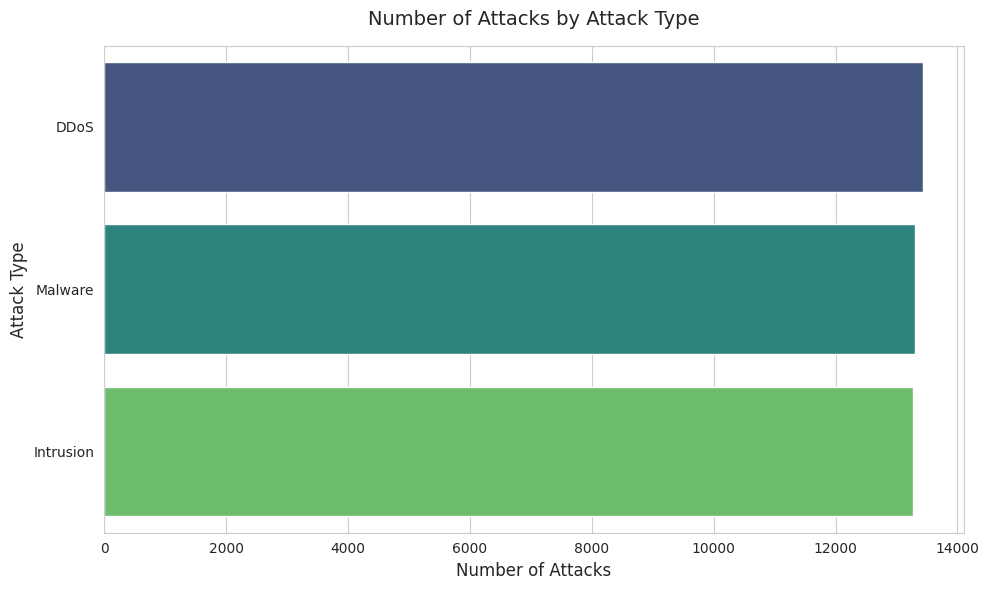

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for all plots (optional but looks better)
sns.set_style("whitegrid")

# Create the bar chart
plt.figure(figsize=(10, 6))

# Use seaborn countplot (very convenient for categorical counts)
sns.countplot(
    data=df, 
    y='Attack Type', 
    order=dfAttack Typ['e'].value_counts().index,
    palette='viridis'
)

plt.title('Number of Attacks by Attack Type', fontsize=14, pad=15)
plt.xlabel('Number of Attacks', fontsize=12)
plt.ylabel('Attack Type', fontsize=12)

# Make sure long labels are readable
plt.tight_layout()

# Save the plot as an image file (you'll need this for the report)
plt.savefig('bar_chart_attack_types.png', dpi=150, bbox_inches='tight')

# Show the plot in the notebook
plt.show()

In [5]:
!ls -lh *.png

-rw-rw-r-- 1 bash bash 38K Feb  7 03:04 bar_chart_attack_types.png


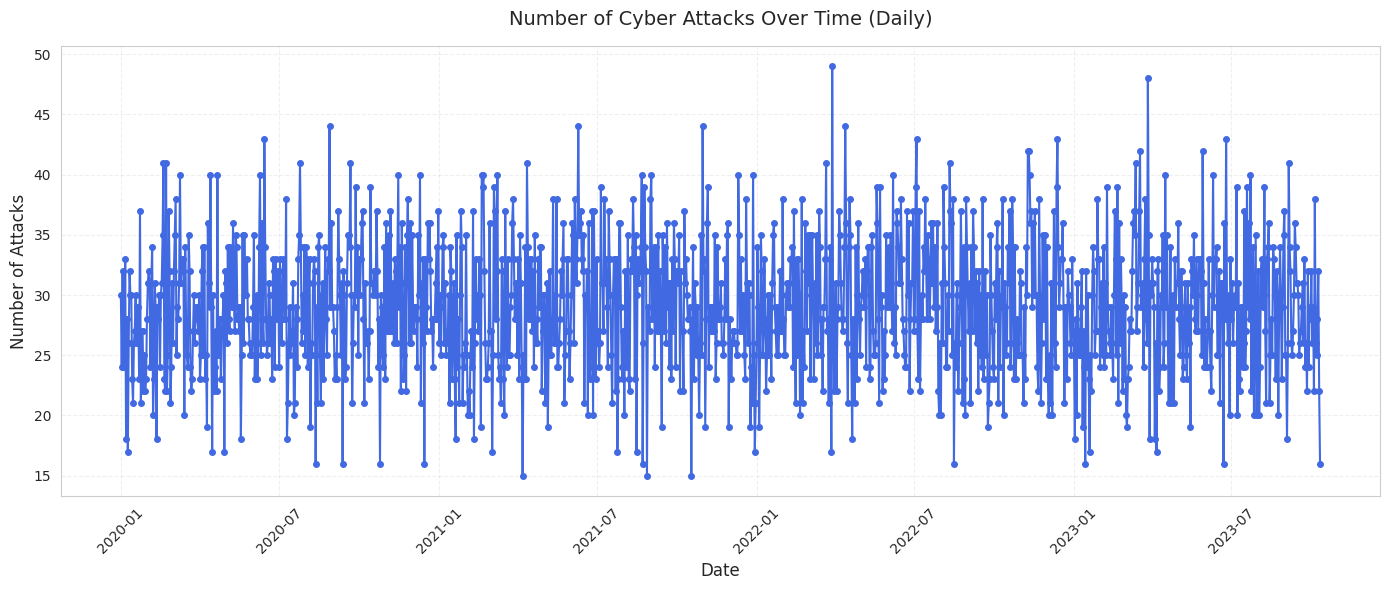

In [6]:
# Group by date (daily) and count the number of attacks each day
daily_attacks = df.groupby(df['Timestamp'].dt.date).size().reset_index(name='Count')

# Convert back to datetime for better plotting
daily_attacks['Date'] = pd.to_datetime(daily_attacks['Timestamp'])

# Create the line chart
plt.figure(figsize=(14, 6))

plt.plot(
    daily_attacks['Date'], 
    daily_attacks['Count'],
    marker='o', 
    linewidth=1.5, 
    markersize=4,
    color='royalblue'
)

plt.title('Number of Cyber Attacks Over Time (Daily)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)

plt.grid(True, alpha=0.3, linestyle='--')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.tight_layout()

# Save the image for your report
plt.savefig('line_chart_attacks_over_time.png', dpi=150, bbox_inches='tight')

plt.show()

In [7]:
!ls -lh *.png

-rw-rw-r-- 1 bash bash  38K Feb  7 03:04 bar_chart_attack_types.png
-rw-rw-r-- 1 bash bash 275K Feb  7 03:08 line_chart_attacks_over_time.png


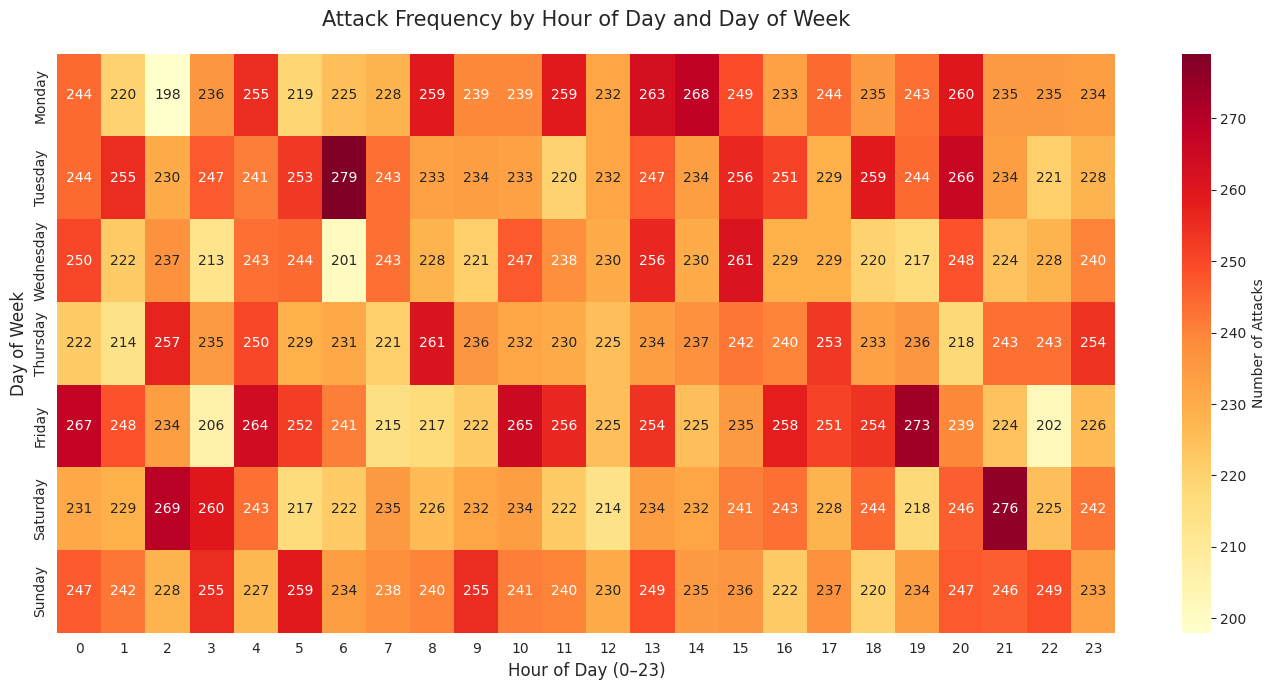

In [8]:
# Extract hour and day-of-week from the Timestamp column
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

# Create a pivot table: rows = day of week, columns = hour, values = count of attacks
heatmap_data = df.pivot_table(
    index='DayOfWeek',
    columns='Hour',
    values='Timestamp',           # we just need any column to count
    aggfunc='count',
    fill_value=0
)

# Reorder days of week in logical order (Monday → Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

# Create the heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',          # yellow-orange-red color scale (high values = red)
    annot=True,             # show numbers in each cell
    fmt='d',                # integer format
    cbar_kws={'label': 'Number of Attacks'}
)

plt.title('Attack Frequency by Hour of Day and Day of Week', fontsize=15, pad=20)
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

plt.tight_layout()

# Save the image for your report
plt.savefig('heatmap_attacks_hour_day.png', dpi=150, bbox_inches='tight')

plt.show()

In [9]:
!ls -lh *.png

-rw-rw-r-- 1 bash bash  38K Feb  7 03:04 bar_chart_attack_types.png
-rw-rw-r-- 1 bash bash 219K Feb  7 03:12 heatmap_attacks_hour_day.png
-rw-rw-r-- 1 bash bash 275K Feb  7 03:08 line_chart_attacks_over_time.png


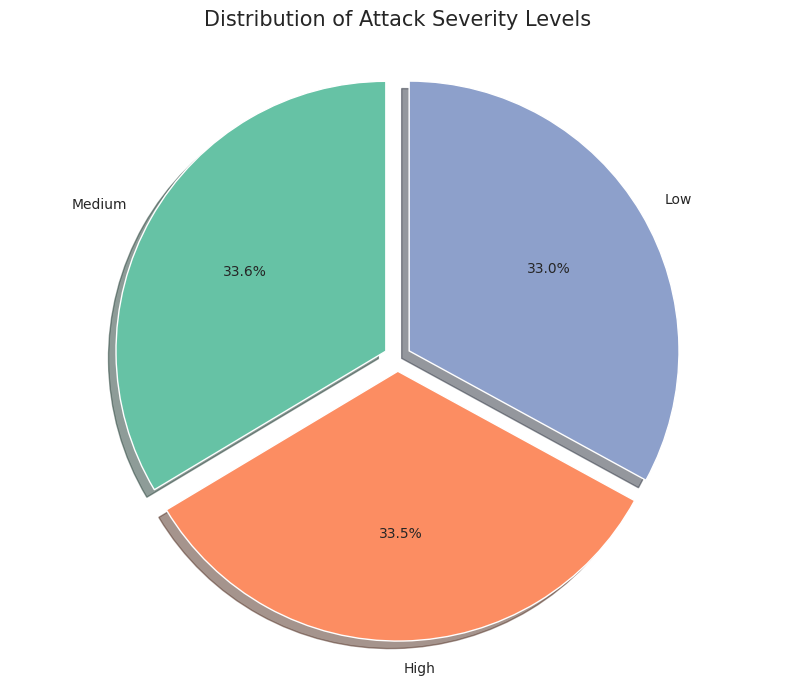

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: set style (consistent with previous plots)
sns.set_style("whitegrid")

# Get the counts of each severity level
severity_counts = df['Severity Level'].value_counts()

# Create the pie chart
plt.figure(figsize=(10, 8))

plt.pie(
    severity_counts,
    labels=severity_counts.index,
    autopct='%1.1f%%',           # show percentage with 1 decimal place
    startangle=90,                # start from top
    colors=sns.color_palette('Set2', len(severity_counts)),
    shadow=True,
    explode=[0.05] * len(severity_counts)   # small separation between slices
)

plt.title('Distribution of Attack Severity Levels', fontsize=15, pad=20)

# Equal aspect ratio ensures the pie is drawn as a circle
plt.axis('equal')

# Save high-quality image for report
plt.savefig('pie_chart_severity_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

In [11]:
!ls -lh *.png


-rw-rw-r-- 1 bash bash  38K Feb  7 03:04 bar_chart_attack_types.png
-rw-rw-r-- 1 bash bash 219K Feb  7 03:12 heatmap_attacks_hour_day.png
-rw-rw-r-- 1 bash bash 275K Feb  7 03:08 line_chart_attacks_over_time.png
-rw-rw-r-- 1 bash bash  94K Feb  7 03:14 pie_chart_severity_distribution.png


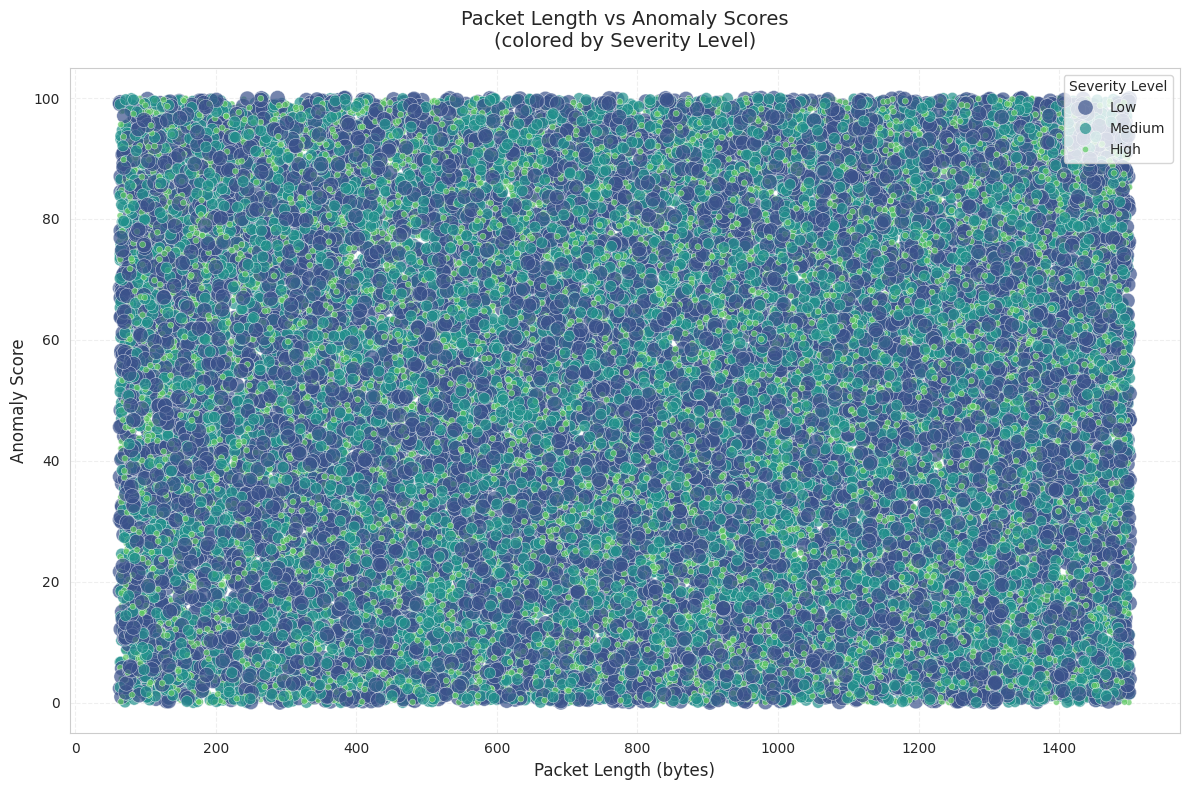

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='Packet Length',
    y='Anomaly Scores',
    hue='Severity Level',
    size='Severity Level',
    palette='viridis',
    alpha=0.7,
    sizes=(20, 120)           # larger points for higher severity
)

plt.title('Packet Length vs Anomaly Scores\n(colored by Severity Level)', 
          fontsize=14, pad=15)

plt.xlabel('Packet Length (bytes)', fontsize=12)
plt.ylabel('Anomaly Score', fontsize=12)

# Add a grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()

# Save high-resolution image for the report
plt.savefig('scatter_packet_vs_anomaly.png', dpi=150, bbox_inches='tight')

plt.show()

In [14]:
!ls -lh *.png


-rw-rw-r-- 1 bash bash  38K Feb  7 03:04 bar_chart_attack_types.png
-rw-rw-r-- 1 bash bash 219K Feb  7 03:12 heatmap_attacks_hour_day.png
-rw-rw-r-- 1 bash bash 275K Feb  7 03:08 line_chart_attacks_over_time.png
-rw-rw-r-- 1 bash bash  94K Feb  7 03:14 pie_chart_severity_distribution.png
-rw-rw-r-- 1 bash bash 3.4M Feb  7 03:19 scatter_packet_vs_anomaly.png
